# STABL baseline study-group feasibility analysis

This notebook replaces the earlier RaJIVE component workflow with a focused `stablr` multinomial elastic-net feasibility analysis. The model is fit once across all eligible baseline samples and predicts study group (`EG`, `GA`, `TU`) regardless of protected (`P`) or non-protected (`NP`) status.

In [1]:
# Runtime controls -------------------------------------------------------------
CYTOF_CELLTYPE_PATH <- "/exports/para-lipg-hpc/Xuran/data/cytof/analysis/clus_freq_clr_combat.csv"
CORE_MULTIVIEW_PATHS <- c(
  cytof_celltype = "/exports/para-lipg-hpc/Xuran/data/cytof/analysis/clus_freq_clr_combat.csv",
  exvivo_celltype = "/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/clus_freq_combat.csv",
  exvivo_enzyme = "/exports/para-lipg-hpc/Xuran/data/aurora_exvivo/analysis/enzyme_celltype_combat.csv"
)
METADATA_PATH <- "/exports/para-lipg-hpc/Xuran/data/metadata.csv"

STABLR_SEED <- 20260512L
STABL_FAMILY <- "multinomial"
STABL_BASE_LEARNER <- "elastic_net"
ELASTIC_NET_L1_RATIO <- 0.5
N_BOOTSTRAPS <- 100L
N_LAMBDA <- 20L
SAMPLE_FRACTION <- 0.75
ARTIFICIAL_TYPE <- "random_permutation"
ARTIFICIAL_PROPORTION <- 1.0
FDR_THRESHOLD_RANGE <- seq(0, 0.99, by = 0.01)
N_WORKERS <- 6L
RUN_CORE_MULTIVIEW <- TRUE
TOP_FALLBACK_FEATURES <- 5L
STUDY_GROUP_MAP <- c(CVTU3 = "TU", EGSV2 = "EG", PfGA2 = "GA")
STUDY_GROUP_LEVELS <- c("EG", "GA", "TU")

In [2]:
# Package setup ----------------------------------------------------------------
find_stablr_pkg_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash = "/", mustWork = TRUE)
  repeat {
    candidates <- c(file.path(path, "r-pkg", "stablr"), path)
    for (candidate in candidates) {
      desc <- file.path(candidate, "DESCRIPTION")
      if (file.exists(desc)) {
        fields <- tryCatch(read.dcf(desc), error = function(e) NULL)
        if (!is.null(fields) && "Package" %in% colnames(fields) &&
            identical(unname(fields[1, "Package"]), "stablr")) {
          return(candidate)
        }
      }
    }
    parent <- dirname(path)
    if (identical(parent, path)) break
    path <- parent
  }
  NA_character_
}

stablr_pkg_root <- find_stablr_pkg_root()
if (!is.na(stablr_pkg_root) && requireNamespace("devtools", quietly = TRUE)) {
  suppressPackageStartupMessages(devtools::load_all(stablr_pkg_root, quiet = TRUE))
} else {
  suppressPackageStartupMessages(library(stablr))
}

required_packages <- c("dplyr", "tidyr", "ggplot2", "tibble", "purrr")
missing_packages <- required_packages[!vapply(required_packages, requireNamespace, logical(1L), quietly = TRUE)]
if (length(missing_packages) > 0L) {
  stop("Install required packages before running this notebook: ",
       paste(missing_packages, collapse = ", "), call. = FALSE)
}
suppressPackageStartupMessages(invisible(lapply(required_packages, library, character.only = TRUE)))

RNGkind("L'Ecuyer-CMRG")
set.seed(STABLR_SEED)


Warning message:
“package ‘testthat’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”
Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘tibble’ was built under R version 4.5.2”


## Helper layer

These helpers are intentionally notebook-local. They keep the feasibility analysis reproducible without expanding the package API.


In [4]:
# Input and preprocessing helpers ---------------------------------------------
read_feature_matrix <- function(path) {
  if (!file.exists(path)) {
    stop("Missing feature matrix: ", path, call. = FALSE)
  }
  x <- read.csv(path, row.names = 1, check.names = FALSE)
  x <- as.matrix(x)
  storage.mode(x) <- "double"
  x
}

read_metadata <- function(path) {
  if (!file.exists(path)) {
    stop("Missing metadata file: ", path, call. = FALSE)
  }
  meta <- read.csv(path, row.names = 1, check.names = FALSE)
  if ("sample_id" %in% names(meta) && identical(rownames(meta), as.character(seq_len(nrow(meta))))) {
    rownames(meta) <- as.character(meta$sample_id)
  }
  if ("sample_id" %in% names(meta)) {
    meta$sample_id <- NULL
  }
  meta
}

add_analysis_labels <- function(meta) {
  meta <- as.data.frame(meta, check.names = FALSE)
  meta$protection <- dplyr::case_when(
    as.character(meta$chmi_qPCR) == "No" ~ "P",
    as.character(meta$chmi_qPCR) == "Yes" ~ "NP",
    TRUE ~ NA_character_
  )
  meta$protection <- factor(meta$protection, levels = c("NP", "P"))
  meta$study_id <- factor(meta$study_id, levels = names(STUDY_GROUP_MAP))
  meta$study_group <- unname(STUDY_GROUP_MAP[as.character(meta$study_id)])
  meta$study_group <- factor(meta$study_group, levels = STUDY_GROUP_LEVELS)
  meta$timepoint <- factor(meta$timepoint, levels = c("t1", "t2", "t3"))
  meta
}

prepare_baseline_view <- function(x, metadata, expected_n = NULL, expected_counts = NULL) {
  meta <- add_analysis_labels(metadata)
  eligible <- rownames(meta)[
    !is.na(meta$timepoint) & meta$timepoint == "t1" &
      !is.na(meta$study_group) &
      rownames(meta) %in% rownames(x)
  ]
  eligible <- eligible[eligible %in% rownames(x)]

  x_out <- x[eligible, , drop = FALSE]
  meta_out <- droplevels(meta[eligible, , drop = FALSE])
  y_out <- stats::setNames(meta_out$study_group, eligible)

  if (anyNA(x_out)) {
    stop("Baseline view contains missing predictor values.", call. = FALSE)
  }
  if (!identical(rownames(x_out), names(y_out))) {
    stop("Predictor and outcome sample order are not aligned.", call. = FALSE)
  }
  if (length(levels(droplevels(y_out))) != 3L) {
    stop("Baseline study-group outcome must contain exactly three classes.", call. = FALSE)
  }
  if (!is.null(expected_n) && nrow(x_out) != expected_n) {
    stop("Expected ", expected_n, " baseline samples, found ", nrow(x_out), ".", call. = FALSE)
  }
  if (!is.null(expected_counts)) {
    observed <- table(y_out)
    if (!all(names(expected_counts) %in% names(observed)) ||
        any(as.integer(observed[names(expected_counts)]) != as.integer(expected_counts))) {
      stop("Unexpected baseline study-group balance: ",
           paste(names(observed), observed, sep = "=", collapse = ", "), call. = FALSE)
    }
  }

  list(x = x_out, y = y_out, metadata = meta_out)
}

near_zero_variance_mask <- function(x, freq_cut = 95 / 5, unique_cut = 10) {
  vapply(seq_len(ncol(x)), function(j) {
    values <- x[, j]
    values <- values[is.finite(values)]
    if (length(values) < 2L) return(TRUE)
    tab <- sort(table(values), decreasing = TRUE)
    freq_ratio <- if (length(tab) <= 1L) Inf else as.numeric(tab[[1L]]) / as.numeric(tab[[2L]])
    percent_unique <- 100 * length(tab) / length(values)
    sd_value <- stats::sd(values)
    zero_variance <- !is.finite(sd_value) || sd_value <= sqrt(.Machine$double.eps)
    zero_variance || (freq_ratio > freq_cut && percent_unique <= unique_cut)
  }, logical(1L))
}

preprocess_predictors <- function(x, view_name = "view") {
  x <- as.matrix(x)
  storage.mode(x) <- "double"
  if (anyNA(x)) {
    stop("Missing values found in ", view_name, " before preprocessing.", call. = FALSE)
  }
  nzv <- near_zero_variance_mask(x)
  keep <- !nzv
  if (!any(keep)) {
    stop("No features remain after near-zero variance filtering for ", view_name, ".", call. = FALSE)
  }
  x_keep <- x[, keep, drop = FALSE]
  x_scaled <- scale(x_keep)
  x_scaled <- as.matrix(x_scaled)
  storage.mode(x_scaled) <- "double"
  if (any(!is.finite(x_scaled))) {
    stop("Non-finite scaled values found in ", view_name, ".", call. = FALSE)
  }

  list(
    x = x_scaled,
    summary = tibble::tibble(
      view = view_name,
      n_samples = nrow(x),
      n_features_raw = ncol(x),
      n_removed_near_zero_variance = sum(nzv),
      n_features_model = ncol(x_scaled)
    ),
    removed_features = colnames(x)[nzv]
  )
}

In [5]:
# STABL and plotting helpers ---------------------------------------------------
fit_stabl_elastic_net <- function(x, y, seed, view_name = "view", bootstrap_strata = NULL) {
  lambda_grid <- auto_lambda_grid(
    x, y,
    family = STABL_FAMILY,
    n_lambda = N_LAMBDA,
    l1_ratio = ELASTIC_NET_L1_RATIO
  )

  fit <- stabl_fit(
    x = x,
    y = y,
    lambda_grid = lambda_grid,
    base_learner = STABL_BASE_LEARNER,
    family = STABL_FAMILY,
    n_bootstraps = N_BOOTSTRAPS,
    artificial_type = ARTIFICIAL_TYPE,
    artificial_proportion = ARTIFICIAL_PROPORTION,
    sample_fraction = SAMPLE_FRACTION,
    replace = FALSE,
    bootstrap_strata = bootstrap_strata,
    random_state = seed,
    workers = N_WORKERS,
    fdr_threshold_range = FDR_THRESHOLD_RANGE
  )

  list(view = view_name, lambda_grid = lambda_grid, fit = fit)
}

importance_table <- function(fit) {
  scores <- get_importances(fit)
  selected <- get_feature_names_out(fit)
  tibble::tibble(
    feature = names(scores),
    stability_score = as.numeric(scores),
    selected = names(scores) %in% selected
  ) |>
    dplyr::arrange(dplyr::desc(.data$selected), dplyr::desc(.data$stability_score), .data$feature)
}

choose_features_for_group_plot <- function(fit, top_n = TOP_FALLBACK_FEATURES) {
  selected <- get_feature_names_out(fit)
  scores <- sort(get_importances(fit), decreasing = TRUE)
  if (length(selected) > 0L) {
    return(list(features = selected, fallback = FALSE))
  }
  fallback_features <- names(scores)[seq_len(min(top_n, length(scores)))]
  list(features = fallback_features, fallback = TRUE)
}

plot_features_by_study_class <- function(features, x, metadata, fallback = FALSE, title = NULL,
                                         facet_by_protection = FALSE) {
  features <- intersect(features, colnames(x))
  if (length(features) == 0L) {
    stop("No requested features are present in the predictor matrix.", call. = FALSE)
  }

  feature_values <- as.data.frame(x[, features, drop = FALSE], check.names = FALSE) |>
    tibble::rownames_to_column("sample_id") |>
    tidyr::pivot_longer(cols = -dplyr::all_of("sample_id"), names_to = "feature", values_to = "value")

  meta_df <- as.data.frame(metadata, check.names = FALSE)
  if ("sample_id" %in% names(meta_df)) {
    meta_df$sample_id <- NULL
  }
  meta_plot <- meta_df |>
    tibble::rownames_to_column("sample_id") |>
    dplyr::select(dplyr::all_of(c("sample_id", "study_group", "protection")))

  plot_df <- feature_values |>
    dplyr::left_join(meta_plot, by = "sample_id") |>
    dplyr::filter(!is.na(.data$study_group))

  if (is.null(title)) {
    title <- if (fallback) {
      "Top stability features by baseline study group"
    } else {
      "Selected STABL features by baseline study group"
    }
  }
  subtitle <- if (fallback) {
    "Exploratory fallback: no features crossed the STABL threshold; plotting top-ranked features."
  } else {
    "Descriptive QC only: STABL was fit once to predict study group, not P/NP status."
  }

  p <- ggplot2::ggplot(plot_df, ggplot2::aes(x = .data$study_group, y = .data$value, fill = .data$study_group)) +
    ggplot2::geom_boxplot(width = 0.6, alpha = 0.8, outlier.shape = NA) +
    ggplot2::geom_jitter(ggplot2::aes(shape = .data$protection), width = 0.12, size = 1.1, alpha = 0.7) +
    ggplot2::labs(title = title, subtitle = subtitle, x = NULL, y = "Scaled feature value", fill = "Study", shape = "P/NP") +
    ggplot2::scale_fill_manual(values = c(EG = "#4C78A8", GA = "#F58518", TU = "#54A24B"), drop = FALSE) +
    ggplot2::theme_bw(base_size = 10) +
    ggplot2::theme(
      legend.position = "top",
      panel.grid.minor = ggplot2::element_blank(),
      strip.text.x = ggplot2::element_text(size = 7),
      strip.text.y = ggplot2::element_text(size = 8, face = "bold"),
      axis.text.x = ggplot2::element_text(angle = 0, hjust = 0.5)
    )

  if (isTRUE(facet_by_protection)) {
    p + ggplot2::facet_grid(.data$protection ~ .data$feature, scales = "free_y")
  } else {
    p + ggplot2::facet_wrap(~ feature, scales = "free_y")
  }
}

plot_features_by_study_and_protection <- function(features, x, metadata, fallback = FALSE, title = NULL) {
  plot_features_by_study_class(
    features = features,
    x = x,
    metadata = metadata,
    fallback = fallback,
    title = title,
    facet_by_protection = TRUE
  )
}

## Single-view pilot: CyTOF cell type

The first feasibility pass uses `cytof_celltype` because it has no missing values in the eligible baseline subset and better coverage than `6h_cyto_ssRNA40`. The target is the three-class study group (`EG`, `GA`, `TU`), with P/NP status ignored by the model.

In [6]:
metadata_raw <- read_metadata(METADATA_PATH)
cytof_raw <- read_feature_matrix(CYTOF_CELLTYPE_PATH)

cytof_baseline <- prepare_baseline_view(
  cytof_raw, metadata_raw,
  expected_n = 38L,
  expected_counts = c(EG = 10L, GA = 16L, TU = 12L)
)

In [7]:
cytof_preprocessed <- preprocess_predictors(cytof_baseline$x, view_name = "cytof_celltype")
x_cytof <- cytof_preprocessed$x
y_cytof <- cytof_baseline$y
metadata_cytof <- cytof_baseline$metadata
cytof_bootstrap_strata <- data.frame(
  study_group = y_cytof,
  row.names = rownames(x_cytof)
)

stopifnot(identical(rownames(x_cytof), names(y_cytof)))
stopifnot(!anyNA(x_cytof))
stopifnot(length(levels(droplevels(y_cytof))) == 3L)
stopifnot(min(table(y_cytof)) >= 10L)

cytof_preprocessed$summary

view,n_samples,n_features_raw,n_removed_near_zero_variance,n_features_model
<chr>,<int>,<int>,<int>,<int>
cytof_celltype,38,125,0,125


In [8]:
cytof_stabl <- fit_stabl_elastic_net(
  x = x_cytof,
  y = y_cytof,
  seed = STABLR_SEED,
  view_name = "cytof_celltype",
  bootstrap_strata = y_cytof
)
fit_cytof <- cytof_stabl$fit
lambda_cytof <- cytof_stabl$lambda_grid

lambda_cytof
fit_cytof

Warning message:
“package ‘future’ was built under R version 4.5.3”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomia

alpha,lambda
<dbl>,<dbl>
0.5,0.752686068
0.5,0.590677896
0.5,0.463540368
0.5,0.363767926
0.5,0.285470507
0.5,0.224025826
0.5,0.175806501
0.5,0.137965904
0.5,0.108270119


<stabl_fit>
  Features in:      125 
  Features selected: 31 
  Min FDP+:         0.0323 
  FDP+ threshold:   0.85 
  Artificial:       random_permutation 

In [9]:
selected_cytof <- get_feature_names_out(fit_cytof)
importance_cytof <- importance_table(fit_cytof)

selected_cytof
head(importance_cytof, 20L)


[1] "clr_5"   "clr_6"   "clr_7"   "clr_9"   "clr_17"  "clr_18"  "clr_19" 
 [8] "clr_20"  "clr_27"  "clr_28"  "clr_30"  "clr_36"  "clr_37"  "clr_38" 
[15] "clr_43"  "clr_46"  "clr_47"  "clr_48"  "clr_53"  "clr_54"  "clr_55" 
[22] "clr_56"  "clr_58"  "clr_63"  "clr_65"  "clr_71"  "clr_74"  "clr_82" 
[29] "clr_91"  "clr_109" "clr_114"

feature,stability_score,selected
<chr>,<dbl>,<lgl>
clr_18,1.00,TRUE
clr_27,1.00,TRUE
clr_30,1.00,TRUE
clr_38,1.00,TRUE
clr_43,1.00,TRUE
clr_46,1.00,TRUE
clr_47,1.00,TRUE
clr_54,1.00,TRUE
clr_56,1.00,TRUE


study_group,feature,beta,abs_beta,lambda_at_max_abs_beta,stability_score,selected,rank_score
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>
EG,clr_7,0.3903004,0.3903004,0.007526861,1.00,TRUE,0.3903004
EG,clr_27,0.3587604,0.3587604,0.007526861,1.00,TRUE,0.3587604
EG,clr_6,0.3008796,0.3008796,0.007526861,1.00,TRUE,0.3008796
EG,clr_54,-0.1711065,0.1711065,0.007526861,1.00,TRUE,0.1711065
EG,clr_47,0.1503688,0.1503688,0.137965904,1.00,TRUE,0.1503688
EG,clr_71,0.1320557,0.1320557,0.007526861,0.99,TRUE,0.1307351
EG,clr_91,0.1266274,0.1266274,0.007526861,1.00,TRUE,0.1266274
EG,clr_5,0.1314436,0.1314436,0.007526861,0.91,TRUE,0.1196137
EG,clr_56,-0.1188573,0.1188573,0.007526861,1.00,TRUE,0.1188573


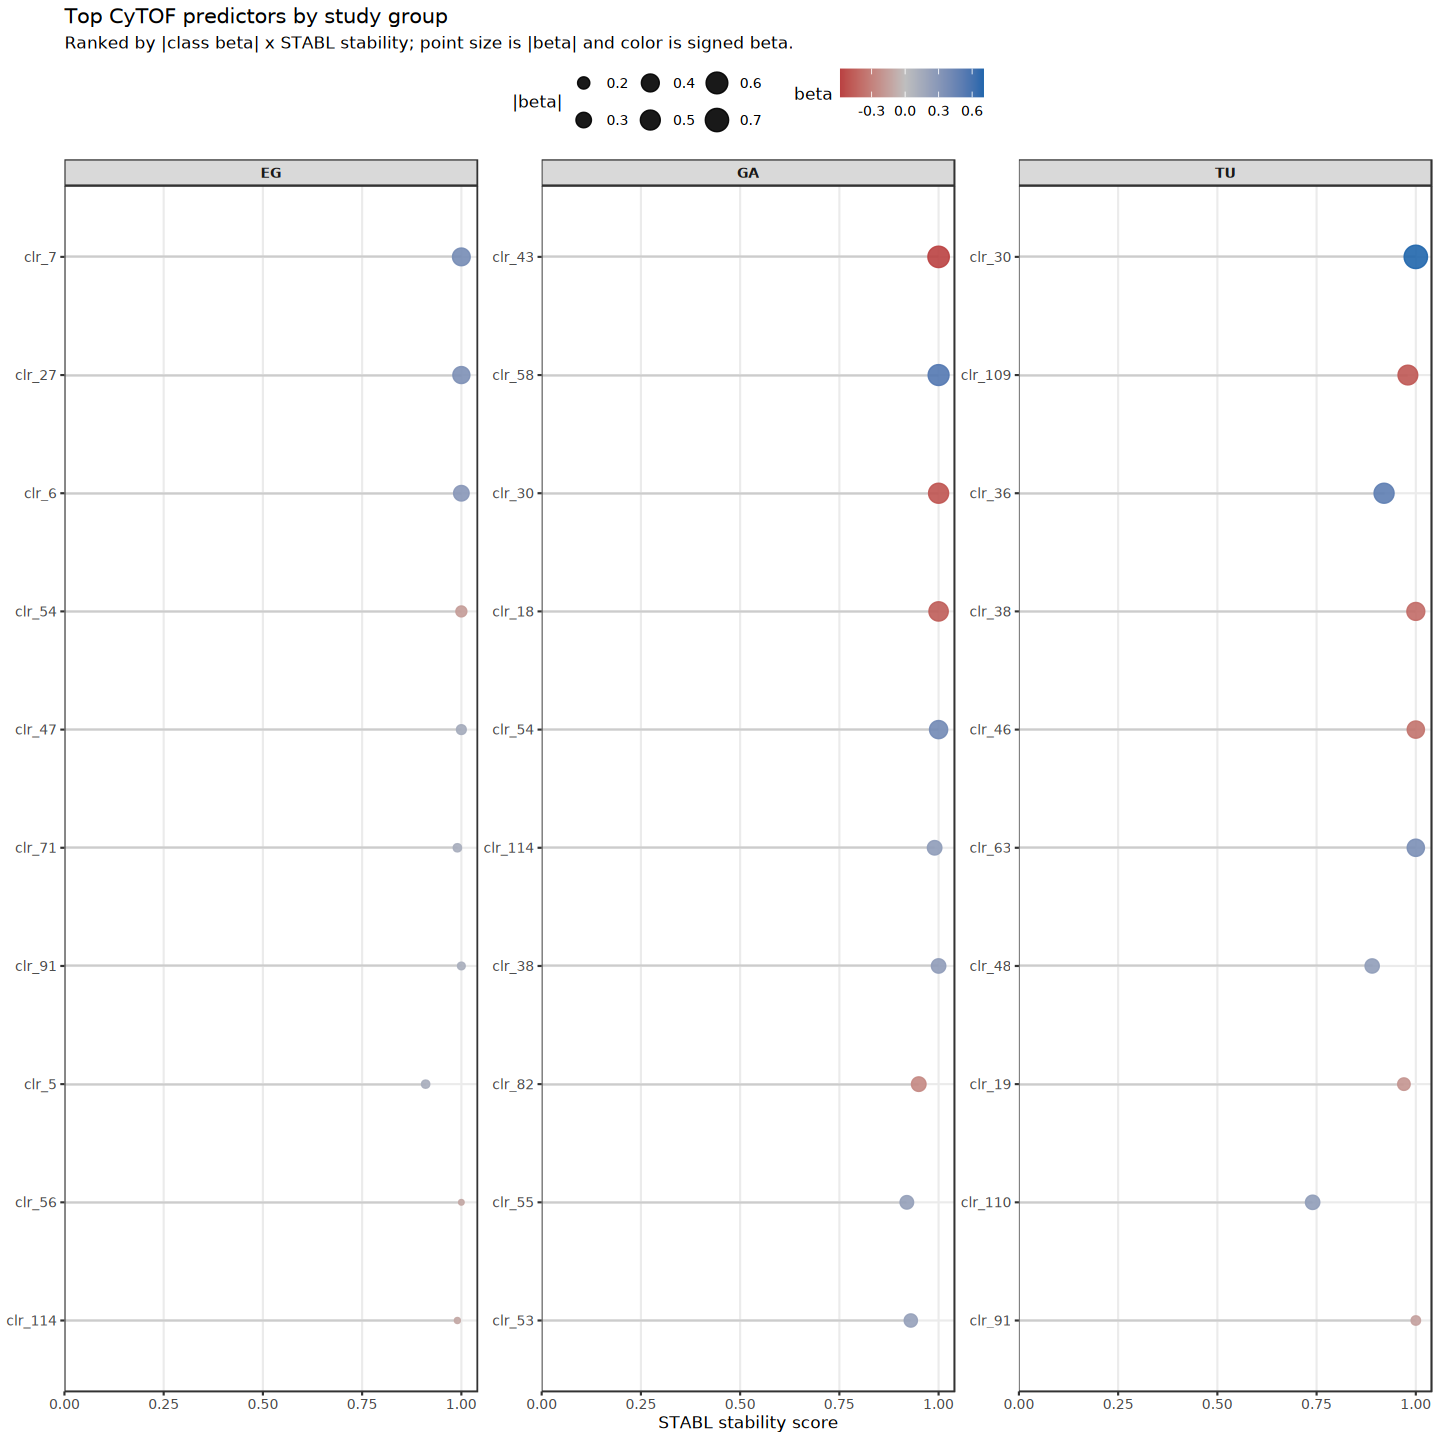

In [20]:
# Class-specific elastic-net beta overlay -------------------------------------
multinomial_elastic_net_beta_table <- function(x, y, lambda_grid, alpha = ELASTIC_NET_L1_RATIO) {
  if (!requireNamespace("glmnet", quietly = TRUE)) {
    stop("Package 'glmnet' is required for coefficient extraction.", call. = FALSE)
  }
  lambdas <- sort(unique(lambda_grid$lambda), decreasing = TRUE)
  beta_fit <- glmnet::glmnet(
    x = x,
    y = y,
    family = "multinomial",
    alpha = alpha,
    lambda = lambdas
  )
  groups <- levels(droplevels(y))

  purrr::map_dfr(groups, function(group) {
    beta_by_lambda <- purrr::map_dfr(lambdas, function(lambda_value) {
      coef_list <- glmnet::coef.glmnet(beta_fit, s = lambda_value)
      if (!group %in% names(coef_list)) {
        stop("Missing multinomial coefficient block for group: ", group, call. = FALSE)
      }
      coef_mat <- coef_list[[group]]
      tibble::tibble(
        study_group = group,
        feature = rownames(coef_mat)[-1L],
        lambda = lambda_value,
        beta = as.numeric(coef_mat[-1L, 1L])
      )
    })

    beta_by_lambda |>
      dplyr::group_by(.data$study_group, .data$feature) |>
      dplyr::slice_max(order_by = abs(.data$beta), n = 1L, with_ties = FALSE) |>
      dplyr::ungroup() |>
      dplyr::transmute(
        study_group = .data$study_group,
        feature = .data$feature,
        beta = .data$beta,
        abs_beta = abs(.data$beta),
        lambda_at_max_abs_beta = .data$lambda
      )
  })
}

top_predictors_by_study_group <- function(fit, x, y, lambda_grid, top_n = 5L) {
  stability <- importance_table(fit) |>
    dplyr::select(.data$feature, .data$stability_score, .data$selected)
  beta_tbl <- multinomial_elastic_net_beta_table(x, y, lambda_grid)

  beta_tbl |>
    dplyr::left_join(stability, by = "feature") |>
    dplyr::mutate(
      stability_score = tidyr::replace_na(.data$stability_score, 0),
      rank_score = .data$abs_beta * .data$stability_score
    ) |>
    dplyr::group_by(.data$study_group) |>
    dplyr::arrange(dplyr::desc(.data$rank_score), dplyr::desc(.data$stability_score), dplyr::desc(.data$abs_beta), .by_group = TRUE) |>
    dplyr::slice_head(n = top_n) |>
    dplyr::ungroup()
}

plot_top_predictors_by_study_group <- function(top_tbl) {
  plot_tbl <- top_tbl |>
    dplyr::group_by(.data$study_group) |>
    dplyr::arrange(.data$rank_score, .by_group = TRUE) |>
    dplyr::mutate(feature_panel = paste(.data$study_group, .data$feature, sep = " || ")) |>
    dplyr::ungroup()
  plot_tbl$feature_panel <- factor(plot_tbl$feature_panel, levels = unique(plot_tbl$feature_panel))

  ggplot2::ggplot(plot_tbl, ggplot2::aes(x = .data$stability_score, y = .data$feature_panel)) +
    ggplot2::geom_segment(ggplot2::aes(x = 0, xend = .data$stability_score, yend = .data$feature_panel), color = "grey80") +
    ggplot2::geom_point(ggplot2::aes(size = .data$abs_beta, color = .data$beta), alpha = 0.9) +
    ggplot2::facet_wrap(~ study_group, scales = "free_y") +
    ggplot2::scale_x_continuous(limits = c(0, 1), expand = ggplot2::expansion(mult = c(0, 0.04))) +
    ggplot2::scale_y_discrete(labels = function(x) sub("^.* \\|\\| ", "", x)) +
    ggplot2::scale_color_gradient2(low = "#B2182B", mid = "grey75", high = "#2166AC", midpoint = 0) +
    ggplot2::labs(
      title = "Top CyTOF predictors by study group",
      subtitle = "Ranked by |class beta| x STABL stability; point size is |beta| and color is signed beta.",
      x = "STABL stability score",
      y = NULL,
      size = "|beta|",
      color = "beta"
    ) +
    ggplot2::theme_bw(base_size = 10) +
    ggplot2::theme(
      legend.position = "top",
      panel.grid.minor = ggplot2::element_blank(),
      strip.text = ggplot2::element_text(face = "bold")
    )
}

cytof_top_predictors_by_group <- top_predictors_by_study_group(
  fit = fit_cytof,
  x = x_cytof,
  y = y_cytof,
  lambda_grid = lambda_cytof,
  top_n = 10L
)
cytof_top_predictors_by_group_plot <- plot_top_predictors_by_study_group(cytof_top_predictors_by_group)

cytof_top_predictors_by_group
cytof_top_predictors_by_group_plot


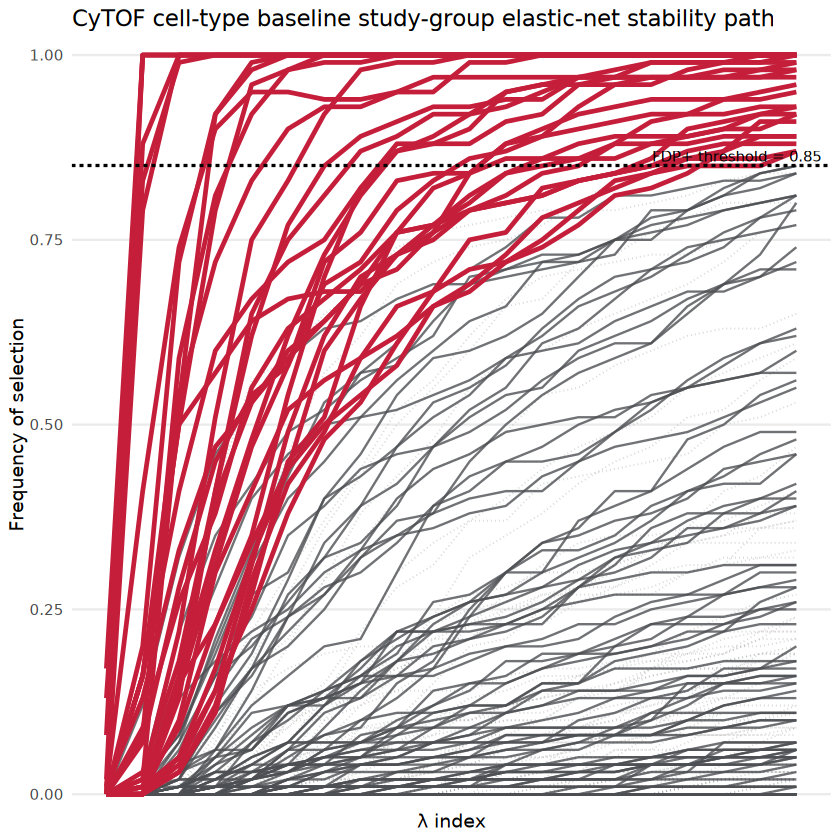

In [11]:
plot_stabl_path(fit_cytof, title = "CyTOF cell-type baseline study-group elastic-net stability path")

$features
 [1] "clr_5"   "clr_6"   "clr_7"   "clr_9"   "clr_17"  "clr_18"  "clr_19" 
 [8] "clr_20"  "clr_27"  "clr_28"  "clr_30"  "clr_36"  "clr_37"  "clr_38" 
[15] "clr_43"  "clr_46"  "clr_47"  "clr_48"  "clr_53"  "clr_54"  "clr_55" 
[22] "clr_56"  "clr_58"  "clr_63"  "clr_65"  "clr_71"  "clr_74"  "clr_82" 
[29] "clr_91"  "clr_109" "clr_114"

$fallback
[1] FALSE

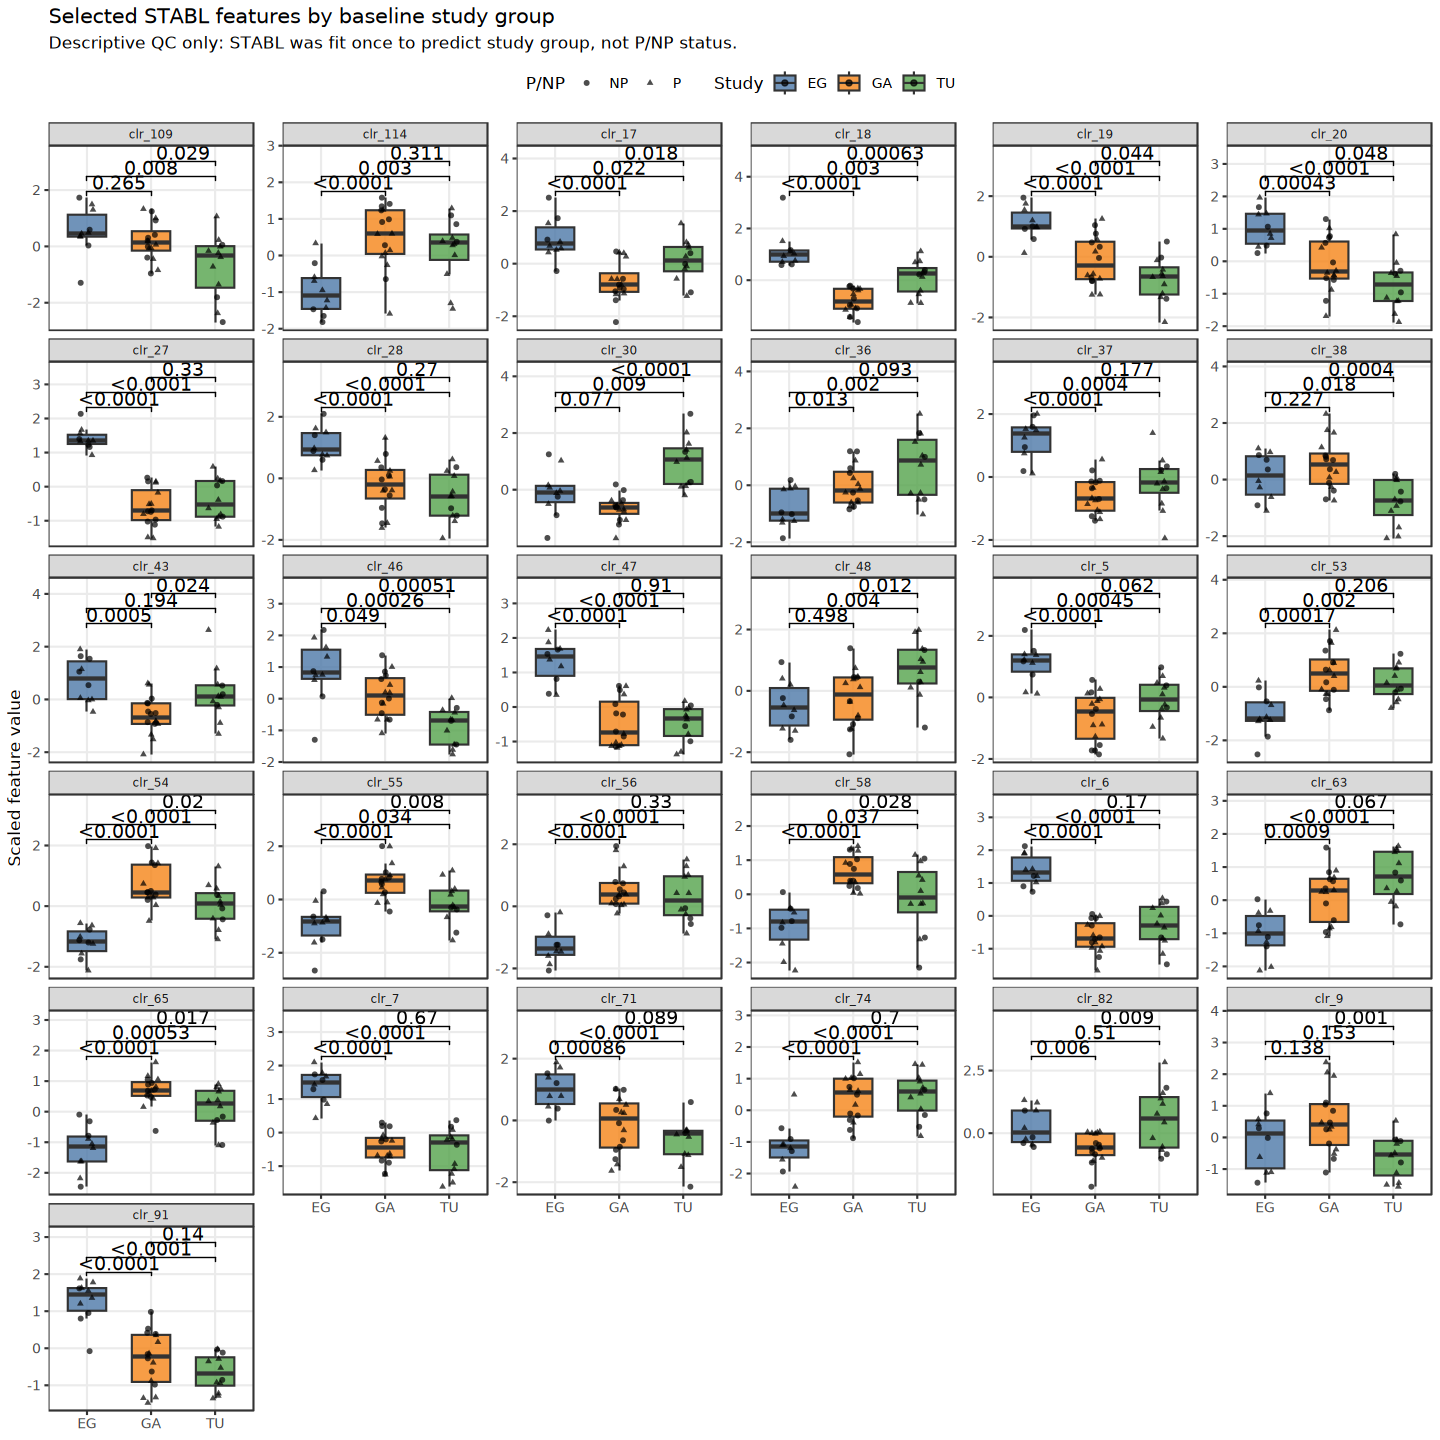

In [12]:
options(repr.plot.width=12, repr.plot.height=12)
cytof_plot_choice <- choose_features_for_group_plot(fit_cytof, top_n = 5)
cytof_features_by_study_plot <- plot_features_by_study_class(
  features = cytof_plot_choice$features,
  x = x_cytof,
  metadata = metadata_cytof,
  fallback = cytof_plot_choice$fallback
) +
  ggpubr::stat_pwc(method = "t_test", p.adjust.method = "none") +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.1)))

cytof_plot_choice
cytof_features_by_study_plot

## Core multiview extension

After the single-view pilot succeeds, the next feasibility pass uses only complete baseline samples shared by `cytof_celltype`, `exvivo_celltype`, and `exvivo_enzyme`. This avoids imputation and keeps the same multinomial study-group target across all P/NP statuses.

In [13]:
prepare_core_multiview <- function(paths, metadata, expected_n = NULL, expected_counts = NULL) {
  blocks <- lapply(paths, read_feature_matrix)
  names(blocks) <- names(paths)

  meta <- add_analysis_labels(metadata)
  eligible <- rownames(meta)[
    !is.na(meta$timepoint) & meta$timepoint == "t1" &
      !is.na(meta$study_group)
  ]
  common_ids <- Reduce(intersect, c(list(eligible), lapply(blocks, rownames)))
  common_ids <- eligible[eligible %in% common_ids]

  blocks <- lapply(blocks, function(x) x[common_ids, , drop = FALSE])
  meta_out <- droplevels(meta[common_ids, , drop = FALSE])
  y_out <- stats::setNames(meta_out$study_group, common_ids)

  if (any(vapply(blocks, function(x) anyNA(x), logical(1L)))) {
    stop("Core multiview blocks contain missing predictor values.", call. = FALSE)
  }
  if (any(!vapply(blocks, function(x) identical(rownames(x), names(y_out)), logical(1L)))) {
    stop("Core multiview sample alignment failed.", call. = FALSE)
  }
  if (length(levels(droplevels(y_out))) != 3L) {
    stop("Core multiview study-group outcome must contain exactly three classes.", call. = FALSE)
  }
  if (!is.null(expected_n) && length(y_out) != expected_n) {
    stop("Expected ", expected_n, " core multiview samples, found ", length(y_out), ".", call. = FALSE)
  }
  if (!is.null(expected_counts)) {
    observed <- table(y_out)
    if (!all(names(expected_counts) %in% names(observed)) ||
        any(as.integer(observed[names(expected_counts)]) != as.integer(expected_counts))) {
      stop("Unexpected core multiview study-group balance: ",
           paste(names(observed), observed, sep = "=", collapse = ", "), call. = FALSE)
    }
  }

  list(x_list = blocks, y = y_out, metadata = meta_out)
}

prefix_feature_names <- function(x, view) {
  x <- as.matrix(x)
  colnames(x) <- paste(view, colnames(x), sep = "__")
  x
}

In [14]:
if (isTRUE(RUN_CORE_MULTIVIEW)) {
  core_multiview <- prepare_core_multiview(
    CORE_MULTIVIEW_PATHS, metadata_raw,
    expected_n = 38L,
    expected_counts = c(EG = 10L, GA = 16L, TU = 12L)
  )

  core_multiview_qc <- purrr::imap_dfr(core_multiview$x_list, function(x, view) {
    tibble::tibble(
      view = view,
      n_samples = nrow(x),
      n_features = ncol(x),
      n_missing = sum(is.na(x))
    )
  })

  core_multiview_class_qc <- as.data.frame(table(core_multiview$y), stringsAsFactors = FALSE) |>
    tibble::as_tibble() |>
    dplyr::rename(study_group = Var1, n = Freq)

  core_multiview_protection_qc <- as.data.frame(table(core_multiview$metadata$study_group, core_multiview$metadata$protection), stringsAsFactors = FALSE) |>
    tibble::as_tibble() |>
    dplyr::rename(study_group = Var1, protection = Var2, n = Freq)

  core_multiview_qc
  core_multiview_class_qc
  core_multiview_protection_qc
}

study_group,protection,n
<chr>,<chr>,<int>
EG,NP,4
GA,NP,8
TU,NP,3
EG,P,6
GA,P,8
TU,P,9


In [15]:
if (isTRUE(RUN_CORE_MULTIVIEW)) {
  core_preprocessed <- purrr::imap(core_multiview$x_list, preprocess_predictors)
  x_core_list <- purrr::map(core_preprocessed, "x")
  core_preprocess_qc <- purrr::map_dfr(core_preprocessed, "summary")

  stopifnot(all(vapply(x_core_list, function(x) identical(rownames(x), names(core_multiview$y)), logical(1L))))
  stopifnot(!any(vapply(x_core_list, function(x) anyNA(x), logical(1L))))
  stopifnot(min(table(core_multiview$y)) >= 10L)

  core_preprocess_qc
}

view,n_samples,n_features_raw,n_removed_near_zero_variance,n_features_model
<chr>,<int>,<int>,<int>,<int>
cytof_celltype,38,125,0,125
exvivo_celltype,38,40,0,40
exvivo_enzyme,38,98,0,98


In [16]:
if (isTRUE(RUN_CORE_MULTIVIEW)) {
  core_bootstrap_strata <- data.frame(
    study_group = core_multiview$y,
    row.names = names(core_multiview$y)
  )

  core_view_fits <- purrr::imap(x_core_list, function(x, view) {
    seed_offset <- match(view, names(x_core_list)) * 100L
    fit_stabl_elastic_net(
      x = x,
      y = core_multiview$y,
      seed = STABLR_SEED + seed_offset,
      view_name = view,
      bootstrap_strata = core_bootstrap_strata
    )
  })

  core_view_selected <- purrr::imap_dfr(core_view_fits, function(result, view) {
    features <- get_feature_names_out(result$fit)
    if (length(features) == 0L) {
      return(tibble::tibble(view = view, feature = character(), selected = logical()))
    }
    tibble::tibble(view = view, feature = features, selected = TRUE)
  })

  core_view_importances <- purrr::imap_dfr(core_view_fits, function(result, view) {
    importance_table(result$fit) |>
      dplyr::mutate(view = view, .before = 1L) |>
      dplyr::slice_head(n = 20L)
  })

  core_view_selected
  core_view_importances
}

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground

view,feature,stability_score,selected
<chr>,<chr>,<dbl>,<lgl>
cytof_celltype,clr_109,1.00,TRUE
cytof_celltype,clr_18,1.00,TRUE
cytof_celltype,clr_19,1.00,TRUE
cytof_celltype,clr_27,1.00,TRUE
cytof_celltype,clr_30,1.00,TRUE
cytof_celltype,clr_38,1.00,TRUE
cytof_celltype,clr_43,1.00,TRUE
cytof_celltype,clr_46,1.00,TRUE
cytof_celltype,clr_47,1.00,TRUE


In [17]:
core_view_importances |> 
    filter(stability_score>.8)

view,feature,stability_score,selected
<chr>,<chr>,<dbl>,<lgl>
cytof_celltype,clr_109,1.00,TRUE
cytof_celltype,clr_18,1.00,TRUE
cytof_celltype,clr_19,1.00,TRUE
cytof_celltype,clr_27,1.00,TRUE
cytof_celltype,clr_30,1.00,TRUE
cytof_celltype,clr_38,1.00,TRUE
cytof_celltype,clr_43,1.00,TRUE
cytof_celltype,clr_46,1.00,TRUE
cytof_celltype,clr_47,1.00,TRUE


In [18]:
if (isTRUE(RUN_CORE_MULTIVIEW)) {
  x_core_early <- do.call(cbind, purrr::imap(x_core_list, prefix_feature_names))

  core_early_stabl <- fit_stabl_elastic_net(
    x = x_core_early,
    y = core_multiview$y,
    seed = STABLR_SEED + 1000L,
    view_name = "core_early_fusion",
    bootstrap_strata = core_bootstrap_strata
  )
  fit_core_early <- core_early_stabl$fit

  core_early_selected <- get_feature_names_out(fit_core_early)
  core_early_importance <- importance_table(fit_core_early)

  core_early_selected
  head(core_early_importance, 30L)
}

Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground”
Warning message in lognet(x, is.sparse, y, weights, offset, alpha, nobs, nvars, :
“one multinomial or binomial class has fewer than 8  observations; dangerous ground

feature,stability_score,selected
<chr>,<dbl>,<lgl>
cytof_celltype__clr_27,1.00,TRUE
cytof_celltype__clr_47,1.00,TRUE
cytof_celltype__clr_54,1.00,TRUE
cytof_celltype__clr_58,1.00,TRUE
cytof_celltype__clr_6,1.00,TRUE
cytof_celltype__clr_7,1.00,TRUE
exvivo_celltype__clustFreqs_Bcells.c15_Atypical_Tbet.CD11c.,1.00,TRUE
exvivo_celltype__clustFreqs_CD4T.c21_Th2,1.00,TRUE
exvivo_celltype__clustFreqs_NK.c38_CD38.,1.00,TRUE


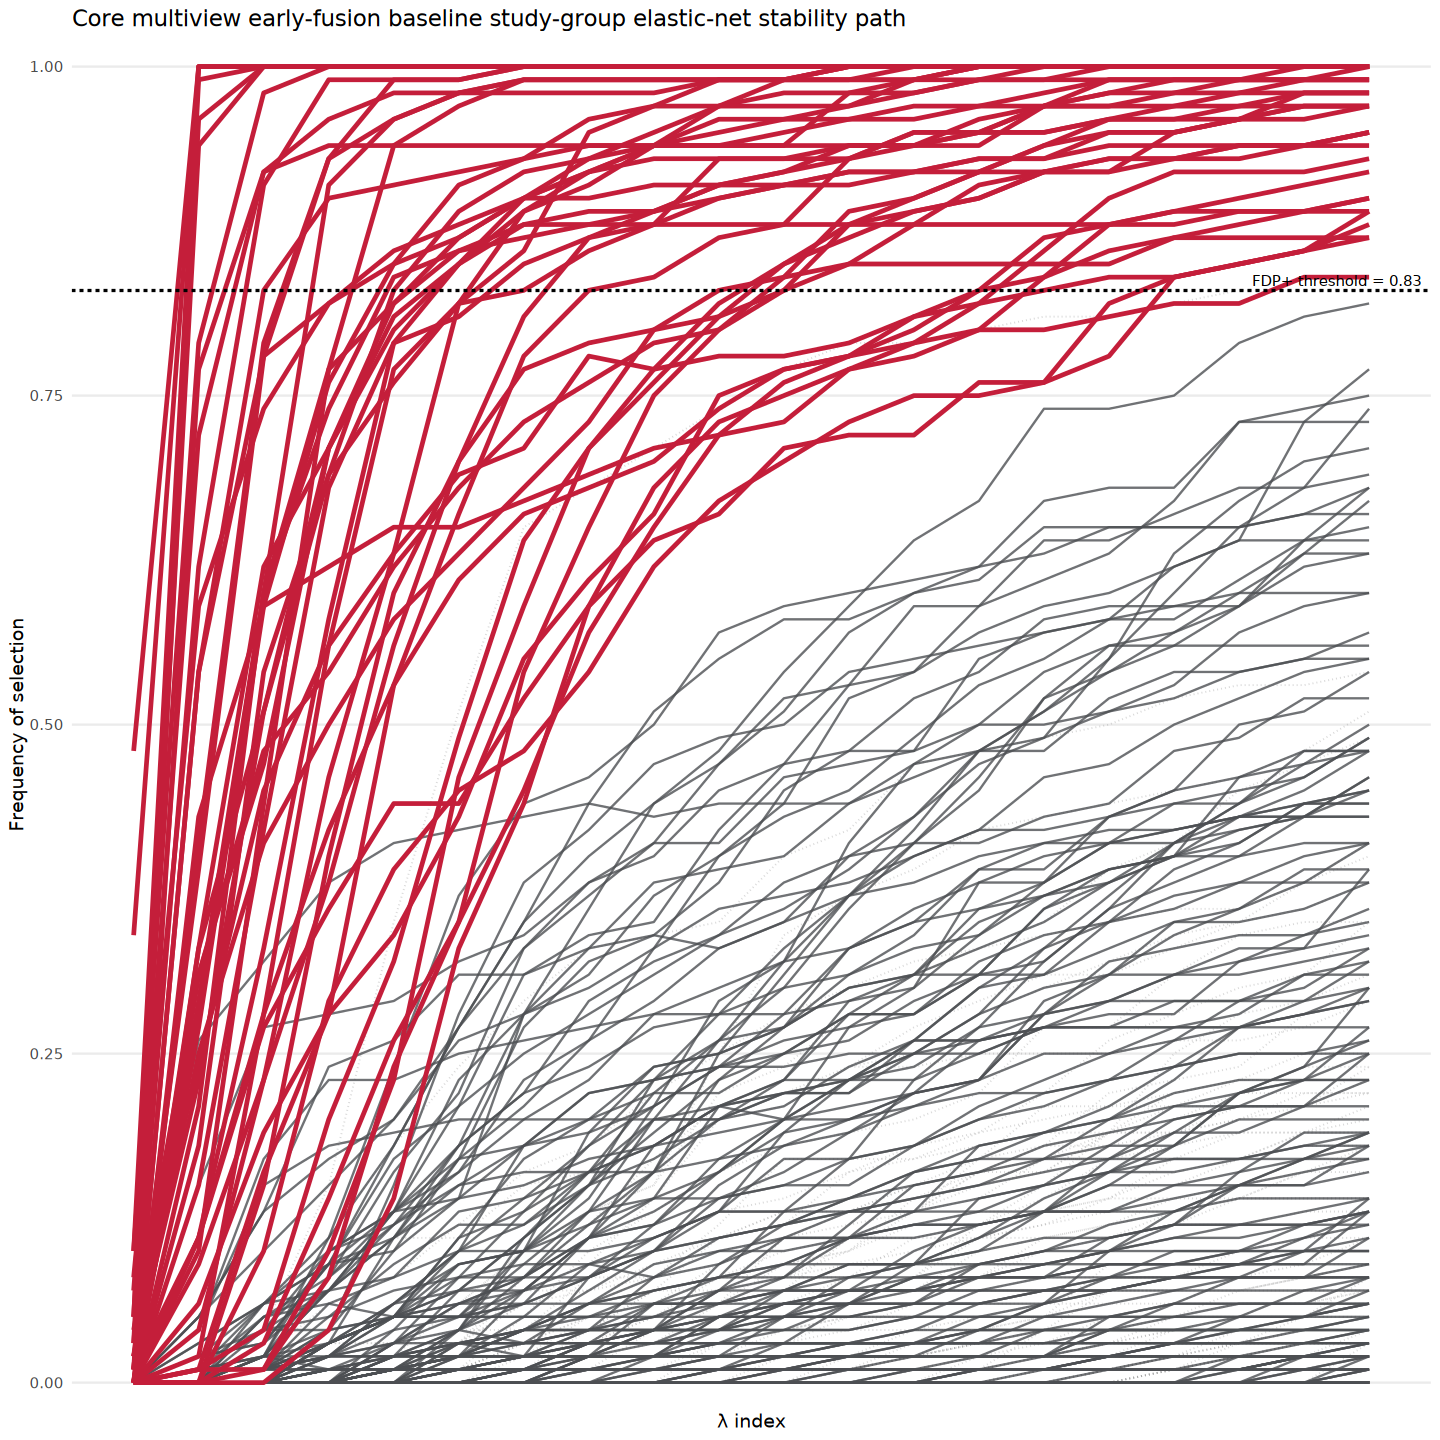

In [19]:
if (isTRUE(RUN_CORE_MULTIVIEW)) {
  plot_stabl_path(fit_core_early, title = "Core multiview early-fusion baseline study-group elastic-net stability path")
}

## Interpretation guardrails

This notebook is a feasibility analysis. With the current feasibility settings (`N_BOOTSTRAPS = 100`, `N_LAMBDA = 20`, `ELASTIC_NET_L1_RATIO = 0.5`, multinomial elastic net), selected features should be treated as candidates for workflow validation, not as biological findings. A publication-grade run should increase bootstrap counts, broaden the lambda/alpha grid, and add validation or resampling appropriate to the scientific question.

This notebook uses random-permutation artificial features for robust execution in the current small-n/high-p setting. Bootstrap samples are stratified by `study_group` only; P/NP status is not used as the outcome, a covariate, or a bootstrap stratum.